# **Rome Airbnb Clusterization**

**Project**: Airbnb Market Segmentation Analysis

**Goal**: Cluster Rome's Airbnb listings using the final feature set from EDA & Feature Selection, testing systematically whether NLP-derived signals reveal market structure invisible to tabular features alone, resolving the geography input, tuning k and gamma, and validating cluster stability before profiling the resulting segments.

## 1. Setup & Preprocessing

### 1.1 Imports & Environment

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import re
import html

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
# Base path configuration
BASE_PATH = Path.cwd().parent

In [3]:
ROME_PALETTE = {
    'primary': '#8B3A3A', 'secondary': '#4C6B8A', 'accent': '#C9A227',
    'neutral': '#6B6B6B', 'light_bg': '#F5F1EC',
}
plt.rcParams.update({
    'figure.dpi': 150, 'font.size': 11, 'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.25,
})

### 1.2 Data Loading

In [4]:
listings = pd.read_csv(BASE_PATH / 'data' / 'processed' / 'listings_final.csv')

In [5]:
listings.drop(columns = ['Unnamed: 0'], inplace = True)
print(f"shape: {listings.shape}")
print(f"\ndtypes:\n{listings.dtypes.value_counts()}")

shape: (35818, 151)

dtypes:
float64    88
str        45
int64      18
Name: count, dtype: int64


### 1.3 Split Off External Variables

In [6]:
EXTERNAL_COLS = ['id', 'price', 'price_tier', 'latitude', 'longitude', 'neighbourhood_cleansed']

listing_ids = listings['id'].copy()
price = listings['price'].copy()
price_tier = listings['price_tier'].copy()
latitude = listings['latitude'].copy()
longitude = listings['longitude'].copy()

print("External variables:")
for name, series in [('listing_ids', listing_ids), ('price', price), ('price_tier', price_tier),
                       ('latitude', latitude), ('longitude', longitude)]:
    print(f"  {name}: {len(series)} values, {series.isna().sum()} NaN")

External variables:
  listing_ids: 35818 values, 0 NaN
  price: 35818 values, 3737 NaN
  price_tier: 35818 values, 0 NaN
  latitude: 35818 values, 0 NaN
  longitude: 35818 values, 0 NaN


### 1.4 The `has_reviews` Strata Split

Several review-derived columns go structurally missing/`Unknown` together for the same ~14% of listings. A listing with no reviews has no sentiment, no review score, no topic content, all at once. Left inside the clustering feature set, this synchronized absence inflates the distance between "has reviews" and "no reviews" listings across many columns simultaneously, risking a cluster defined by that one structural fact rather than by genuine market segmentation. Listings without reviews are set aside here for separate, descriptive profiling later, and clustering runs only on the population that actually has review data.

In [7]:
print(f"has_reviews value counts:\n{listings['has_reviews'].value_counts()}")

listings_no_review = listings[listings['has_reviews'] == 0].copy()
listings_reviewed = listings[listings['has_reviews'] == 1].copy()

print(f"\nlistings_no_review: {listings_no_review.shape[0]} rows ({listings_no_review.shape[0]/len(listings)*100:.1f}%)")
print(f"listings_reviewed: {listings_reviewed.shape[0]} rows ({listings_reviewed.shape[0]/len(listings)*100:.1f}%)")
print(f"\nrows accounted for: {listings_no_review.shape[0] + listings_reviewed.shape[0]} vs total {len(listings)}")


listing_ids = listing_ids.loc[listings_reviewed.index]
price = price.loc[listings_reviewed.index]
price_tier = price_tier.loc[listings_reviewed.index]
latitude = latitude.loc[listings_reviewed.index]
longitude = longitude.loc[listings_reviewed.index]

print(f"\nexternal variables re-aligned to listings_reviewed: {len(listing_ids)} rows each")

has_reviews value counts:
has_reviews
1    30718
0     5100
Name: count, dtype: int64

listings_no_review: 5100 rows (14.2%)
listings_reviewed: 30718 rows (85.8%)

rows accounted for: 35818 vs total 35818

external variables re-aligned to listings_reviewed: 30718 rows each


### 1.5 Splitting Features by Type

In [8]:
str_cols = listings_reviewed.select_dtypes(include='str').columns.tolist()
numeric_all = listings_reviewed.select_dtypes(include=[np.number]).columns.tolist()

EXCLUDE_FROM_NUMERIC = {'id', 'price', 'latitude', 'longitude'}
EXCLUDE_FROM_CAT = {'neighbourhood_cleansed'}

binary_cols = [c for c in numeric_all if c not in EXCLUDE_FROM_NUMERIC
               and set(listings_reviewed[c].dropna().unique()).issubset({0, 1})]
continuous_cols = [c for c in numeric_all if c not in binary_cols and c not in EXCLUDE_FROM_NUMERIC]
categorical_cols = [c for c in str_cols if c not in EXCLUDE_FROM_CAT and c != 'price_tier']

print(f"binary flags: {len(binary_cols)}")
print(f"continuous numeric: {len(continuous_cols)}")
print(f"string/nominal categorical: {len(categorical_cols)}")

all_clustering_cols = binary_cols + continuous_cols + categorical_cols
print(f"\ntotal clustering-input columns: {len(all_clustering_cols)}")
print(f"total listings_reviewed columns: {listings_reviewed.shape[1]}")
print(f"expected gap: {listings_reviewed.shape[1] - len(all_clustering_cols)}")

binary flags: 29
continuous numeric: 73
string/nominal categorical: 43

total clustering-input columns: 145
total listings_reviewed columns: 151
expected gap: 6


### 1.6 NLP vs. Tabular Classification

In [9]:
POST_STRATA_EXCLUDE = {'has_reviews', 'number_of_reviews'}
binary_cols = [c for c in binary_cols if c not in POST_STRATA_EXCLUDE]
continuous_cols = [c for c in continuous_cols if c not in POST_STRATA_EXCLUDE]

REDUNDANT_EXCLUDE = {'has_top5_amenity', 'portfolio_size_bin'}
binary_cols = [c for c in binary_cols if c not in REDUNDANT_EXCLUDE]
continuous_cols = [c for c in continuous_cols if c not in REDUNDANT_EXCLUDE]
categorical_cols = [c for c in categorical_cols if c not in REDUNDANT_EXCLUDE]

all_clustering_cols = binary_cols + continuous_cols + categorical_cols
all_clustering_cols_set = set(all_clustering_cols)

TABULAR_STRUCTURAL_COLS = {
    'geo_sector', 'distance_to_center_km_log',
    'property_type_grouped', 'accommodates_bin', 'accommodates_per_bedroom_binned',
    'bedrooms_binned', 'bathroom_count', 'beds_log', 'amenities_count',
    'has_outdoor_leisure', 'has_fireplace', 'has_hot_tub', 'has_bbq', 'has_gym',
    'bath_private_info', 'bath_shared_info',
    'is_long_term_oriented', 'availability_ratio', 'availability_365_ratio', 'instant_bookable',
    'host_response_time', 'host_response_rate_binned', 'host_acceptance_rate_binned',
    'host_is_superhost', 'host_experience_years', 'calculated_host_listings_count_log',
    'median_review_length', 'reviews_per_month_binned', 'last_review_recency_binned',
    'review_engagement_score', 'review_quality_pc1_binned',
    'has_description', 'has_neighborhood_overview', 'has_host_about', 'has_response_data',
}

# check if every "tabular" name must actually exist in the data
phantom_tabular = TABULAR_STRUCTURAL_COLS - all_clustering_cols_set
assert not phantom_tabular, f"TABULAR_STRUCTURAL_COLS contains names not in the actual data: {phantom_tabular}"

NLP_COLS = all_clustering_cols_set - TABULAR_STRUCTURAL_COLS

print(f"total clustering columns: {len(all_clustering_cols_set)}")
print(f"tabular : {len(TABULAR_STRUCTURAL_COLS)}")
print(f"NLP : {len(NLP_COLS)}")

# check
assert len(TABULAR_STRUCTURAL_COLS) + len(NLP_COLS) == len(all_clustering_cols_set)

print(f"\nNLP_COLS ({len(NLP_COLS)} total):")
for col in sorted(NLP_COLS):
    print(f"  {col}")

total clustering columns: 141
tabular : 35
NLP : 106

NLP_COLS (106 total):
  desc_topic_amenities_wifi_ac_tv_weight
  desc_topic_bedroom_layout_weight
  desc_topic_building_character_weight
  desc_topic_metro_distance_meters_weight
  desc_topic_multi_bedroom_large_weight
  desc_topic_navona_pantheon_campo_fiori_weight_binned
  desc_topic_near_attractions_general_weight
  desc_topic_neighborhood_liveliness_weight
  desc_topic_piazza_spagna_trevi_weight
  desc_topic_room_type_private_shared_weight
  desc_topic_san_giovanni_colosseum_weight_binned
  desc_topic_termini_train_airport_weight
  desc_topic_vatican_museums_weight
  desc_topic_walk_minutes_weight
  description_atmosphere_lively_density_log
  description_atmosphere_quiet_density_log
  description_authenticity_density_log
  description_budget_density_binned
  description_direct_address_density_log
  description_exclaim_count_binned
  description_family_density_binned
  description_landmark_count_log
  description_luxury_density_l

### 1.7 Ordinal Recoding for the Ordered Categories

Some categorical columns encode a real, such as `1 Bedroom` is meaningfully "less" than `3+ Bedrooms`, but as plain strings, Gower/Hamming distance treats every mismatch identically, whether it's `Studio` vs. `1 Bedroom` or `Studio` vs. `3+ Bedrooms`. Recoding these as small integers and placing them in the continuous block preserves that ordering information instead of discarding it. Only columns with a genuinely unambiguous, total order are recoded this way, anything with ties, an `Unknown`/non-ordered category, or no natural ranking stays in the categorical block as-is.

In [10]:
final_categorical_cols = [c for c in categorical_cols]  

print(f"{len(final_categorical_cols)} categorical columns to review:\n")
for col in sorted(final_categorical_cols):
    categories = sorted(listings_reviewed[col].unique())
    print(f"{col} ({len(categories)}): {categories}")

42 categorical columns to review:

accommodates_bin (4): ['1-2', '3-4', '5-6', '7+']
accommodates_per_bedroom_binned (5): ['High', 'Low', 'Studio', 'Typical', 'Unknown']
bedrooms_binned (5): ['1 Bedroom', '2 Bedrooms', '3+ Bedrooms', 'Studio', 'Unknown']
desc_topic_navona_pantheon_campo_fiori_weight_binned (4): ['Unknown', 'high', 'low', 'none']
desc_topic_san_giovanni_colosseum_weight_binned (4): ['Unknown', 'high', 'low', 'none']
description_budget_density_binned (4): ['Unknown', 'high', 'low', 'none']
description_exclaim_count_binned (4): ['0', '1', '2+', 'Unknown']
description_family_density_binned (4): ['Unknown', 'high', 'low', 'none']
description_mtld_binned (4): ['High', 'Low', 'Medium', 'Unknown']
description_readability_binned (4): ['High', 'Low', 'Medium', 'Unknown']
description_romantic_density_binned (4): ['Unknown', 'high', 'low', 'none']
description_we_ref_density_binned (4): ['Unknown', 'high', 'low', 'none']
geo_sector (8): ['E', 'N', 'NE', 'NW', 'S', 'SE', 'SW', 'W']


In [11]:
UNKNOWN_SYNONYMS = {'unavailable', 'unknown', 'nan', 'none_available'}
CASE_PRESERVE_COLS = {'geo_sector'}  

def normalize_category_labels(series, preserve_case=False):
    """Lowercases every label for consistency (unless preserve_case), then folds
    any unknown-synonym (case-insensitive) into a single canonical 'unknown' label."""
    cleaned = series.astype(str).str.strip()
    is_unknown_variant = cleaned.str.lower().isin(UNKNOWN_SYNONYMS)
    if not preserve_case:
        cleaned = cleaned.str.lower()
    cleaned = cleaned.where(~is_unknown_variant, 'unknown')
    return cleaned

normalization_report = []
for col in categorical_cols:
    before = set(listings_reviewed[col].unique())
    listings_reviewed[col] = normalize_category_labels(listings_reviewed[col], preserve_case=col in CASE_PRESERVE_COLS)
    after = set(listings_reviewed[col].unique())
    if before != after:
        normalization_report.append({'column': col, 'before': sorted(before), 'after': sorted(after)})

print(f"{len(normalization_report)} columns had labels normalized:\n")
for entry in normalization_report:
    print(f"{entry['column']}:")
    print(f"  before: {entry['before']}")
    print(f"  after:  {entry['after']}")
    print()

40 columns had labels normalized:

host_response_time:
  before: ['Unknown', 'a few days or more', 'within a day', 'within a few hours', 'within an hour']
  after:  ['a few days or more', 'unknown', 'within a day', 'within a few hours', 'within an hour']

bedrooms_binned:
  before: ['1 Bedroom', '2 Bedrooms', '3+ Bedrooms', 'Studio', 'Unknown']
  after:  ['1 bedroom', '2 bedrooms', '3+ bedrooms', 'studio', 'unknown']

host_acceptance_rate_binned:
  before: ['Full Acceptance', 'Partial Acceptance', 'Unknown']
  after:  ['full acceptance', 'partial acceptance', 'unknown']

host_response_rate_binned:
  before: ['Full Response', 'Partial Response', 'Unknown']
  after:  ['full response', 'partial response', 'unknown']

reviews_per_month_binned:
  before: ['High Demand', 'Low Demand', 'Moderate Demand']
  after:  ['high demand', 'low demand', 'moderate demand']

last_review_recency_binned:
  before: ['Active', 'Dormant', 'Moderate']
  after:  ['active', 'dormant', 'moderate']

property_type_

Four columns carry a genuine order and no `Unknown` category at all: guest capacity tiers, review recency, review demand level, and review quality. As plain strings, Hamming distance would treat any two mismatched categories as equally different, discarding the fact that `1-2` sits closer to `3-4` than to `7+`. Recoding these as small integers and moving them into the continuous block preserves that ordering directly in the distance calculation instead of losing it.

In [12]:
# direct ordinal recode
GROUP_A_ORDINAL_MAPS = {
    'accommodates_bin': {'1-2': 0, '3-4': 1, '5-6': 2, '7+': 3},
    'last_review_recency_binned': {'active': 0, 'moderate': 1, 'dormant': 2},
    'reviews_per_month_binned': {'low demand': 0, 'moderate demand': 1, 'high demand': 2},
    'review_quality_pc1_binned': {'below average': 0, 'above average': 1},
}

for col, mapping in GROUP_A_ORDINAL_MAPS.items():
    actual = set(listings_reviewed[col].unique())
    expected = set(mapping.keys())
    assert actual == expected, f"{col}: actual={sorted(actual)} != expected={sorted(expected)}"

    listings_reviewed[f'{col}_ordinal'] = listings_reviewed[col].map(mapping)
    assert listings_reviewed[f'{col}_ordinal'].isna().sum() == 0, f"{col}_ordinal has unexpected NaN after mapping"

    # move from categorical to continuous
    categorical_cols.remove(col)
    continuous_cols.append(f'{col}_ordinal')

    print(f"{col} -> {col}_ordinal: {mapping}")

accommodates_bin -> accommodates_bin_ordinal: {'1-2': 0, '3-4': 1, '5-6': 2, '7+': 3}
last_review_recency_binned -> last_review_recency_binned_ordinal: {'active': 0, 'moderate': 1, 'dormant': 2}
reviews_per_month_binned -> reviews_per_month_binned_ordinal: {'low demand': 0, 'moderate demand': 1, 'high demand': 2}
review_quality_pc1_binned -> review_quality_pc1_binned_ordinal: {'below average': 0, 'above average': 1}


These eight tone/topic columns already carry a `none` level, meaning "the field existed, and this theme was measured at exactly zero." Their `Unknown` values, however, all trace back to the same underlying fact already recorded elsewhere in the feature set: the source field itself was never filled in. Since that fact is already captured independently, keeping `Unknown` as a separate category here would just count the same missing-field signal twice. `Unknown` is merged into `none`, and the resulting three clean levels (`none`/`low`/`high`, or `0`/`1`/`2+` for the exclaim-count column) are recoded as ordinal integers and moved into the continuous block.

In [13]:
# merge unknown -> none, then ordinal recode

GROUP_B_ORDINAL_MAPS = {
    'description_budget_density_binned': {'none': 0, 'low': 1, 'high': 2},
    'description_family_density_binned': {'none': 0, 'low': 1, 'high': 2},
    'description_romantic_density_binned': {'none': 0, 'low': 1, 'high': 2},
    'description_we_ref_density_binned': {'none': 0, 'low': 1, 'high': 2},
    'host_about_family_density_binned': {'none': 0, 'low': 1, 'high': 2},
    'neighborhood_overview_luxury_density_binned': {'none': 0, 'low': 1, 'high': 2},
    'neighborhood_overview_we_ref_density_binned': {'none': 0, 'low': 1, 'high': 2},
    'description_exclaim_count_binned': {'0': 0, '1': 1, '2+': 2},
}

for col, mapping in GROUP_B_ORDINAL_MAPS.items():
    # merge unknown -> none 
    zero_label = '0' if col == 'description_exclaim_count_binned' else 'none'
    before_unknown = (listings_reviewed[col] == 'unknown').sum()
    listings_reviewed[col] = listings_reviewed[col].replace('unknown', zero_label)
    after_unknown = (listings_reviewed[col] == 'unknown').sum()

    # verify categories match expectation exactly before mapping
    actual = set(listings_reviewed[col].unique())
    expected = set(mapping.keys())
    assert actual == expected, f"{col}: actual={sorted(actual)} != expected={sorted(expected)}"

    listings_reviewed[f'{col}_ordinal'] = listings_reviewed[col].map(mapping)
    assert listings_reviewed[f'{col}_ordinal'].isna().sum() == 0, f"{col}_ordinal has unexpected NaN after mapping"

    # move from categorical to continuous
    categorical_cols.remove(col)
    continuous_cols.append(f'{col}_ordinal')

    print(f"{col}: merged {before_unknown} unknown -> {zero_label} ({after_unknown} remain), then recoded {mapping}")

description_budget_density_binned: merged 793 unknown -> none (0 remain), then recoded {'none': 0, 'low': 1, 'high': 2}
description_family_density_binned: merged 793 unknown -> none (0 remain), then recoded {'none': 0, 'low': 1, 'high': 2}
description_romantic_density_binned: merged 793 unknown -> none (0 remain), then recoded {'none': 0, 'low': 1, 'high': 2}
description_we_ref_density_binned: merged 793 unknown -> none (0 remain), then recoded {'none': 0, 'low': 1, 'high': 2}
host_about_family_density_binned: merged 16802 unknown -> none (0 remain), then recoded {'none': 0, 'low': 1, 'high': 2}
neighborhood_overview_luxury_density_binned: merged 15227 unknown -> none (0 remain), then recoded {'none': 0, 'low': 1, 'high': 2}
neighborhood_overview_we_ref_density_binned: merged 15227 unknown -> none (0 remain), then recoded {'none': 0, 'low': 1, 'high': 2}
description_exclaim_count_binned: merged 741 unknown -> 0 (0 remain), then recoded {'0': 0, '1': 1, '2+': 2}


In [14]:
GROUP_A_ORIGINAL_COLS = list(GROUP_A_ORDINAL_MAPS.keys())
GROUP_B_ORIGINAL_COLS = list(GROUP_B_ORDINAL_MAPS.keys())

cols_to_drop = GROUP_A_ORIGINAL_COLS + GROUP_B_ORIGINAL_COLS
still_present = [c for c in cols_to_drop if c in listings_reviewed.columns]
print(f"dropping {len(still_present)} superseded columns: {still_present}")

listings_reviewed = listings_reviewed.drop(columns=still_present)

# sanity check
leftover_in_tracking = set(cols_to_drop) & (set(categorical_cols) | set(continuous_cols) | set(binary_cols))
print(f"leftover old names in tracking lists: {leftover_in_tracking if leftover_in_tracking else 'none'}")

print(f"\nlistings_reviewed shape: {listings_reviewed.shape}")

dropping 12 superseded columns: ['accommodates_bin', 'last_review_recency_binned', 'reviews_per_month_binned', 'review_quality_pc1_binned', 'description_budget_density_binned', 'description_family_density_binned', 'description_romantic_density_binned', 'description_we_ref_density_binned', 'host_about_family_density_binned', 'neighborhood_overview_luxury_density_binned', 'neighborhood_overview_we_ref_density_binned', 'description_exclaim_count_binned']
leftover old names in tracking lists: none

listings_reviewed shape: (30718, 151)


In [16]:
# swap the 4 Group A tabular columns' old names for their new _ordinal names in
# TABULAR_STRUCTURAL_COLS — the 8 Group B columns need no such swap, since they
# were already NLP and NLP_COLS is derived as the complement, not listed by hand
TABULAR_STRUCTURAL_COLS -= set(GROUP_A_ORIGINAL_COLS)
TABULAR_STRUCTURAL_COLS |= {f'{c}_ordinal' for c in GROUP_A_ORIGINAL_COLS}

# rebuild the master list and verify no leaks, no phantoms, no double-counting
all_clustering_cols = binary_cols + continuous_cols + categorical_cols
all_clustering_cols_set = set(all_clustering_cols)

phantom_tabular = TABULAR_STRUCTURAL_COLS - all_clustering_cols_set
NLP_COLS = all_clustering_cols_set - TABULAR_STRUCTURAL_COLS

assert not phantom_tabular, f"phantom tabular entries: {phantom_tabular}"
assert len(TABULAR_STRUCTURAL_COLS) + len(NLP_COLS) == len(all_clustering_cols_set)

print(f"listings_reviewed shape: {listings_reviewed.shape}")
print(f"categorical_cols: {len(categorical_cols)} (Group C only)")
print(f"continuous_cols: {len(continuous_cols)} (+12 from Groups A/B)")
print(f"total clustering columns: {len(all_clustering_cols_set)}")
print(f"tabular: {len(TABULAR_STRUCTURAL_COLS)}, NLP: {len(NLP_COLS)}")

listings_reviewed shape: (30718, 151)
categorical_cols: 30 (Group C only)
continuous_cols: 84 (+12 from Groups A/B)
total clustering columns: 141
tabular: 35, NLP: 106


In [17]:
print(f"binary_cols count: {len(binary_cols)}")
print(binary_cols)

# sanity check: confirm none of the 29 binary flags accidentally ended up in
# continuous_cols or categorical_cols already — they should exist only in
# their own tracked list until assembly
overlap_with_continuous = set(binary_cols) & set(continuous_cols)
overlap_with_categorical = set(binary_cols) & set(categorical_cols)
print(f"\noverlap with continuous_cols (MUST be empty): {overlap_with_continuous if overlap_with_continuous else 'none'}")
print(f"overlap with categorical_cols (MUST be empty): {overlap_with_categorical if overlap_with_categorical else 'none'}")

binary_cols count: 27
['host_is_superhost', 'instant_bookable', 'bath_private_info', 'bath_shared_info', 'has_outdoor_leisure', 'has_fireplace', 'has_hot_tub', 'has_bbq', 'has_gym', 'has_response_data', 'is_long_term_oriented', 'has_description', 'has_neighborhood_overview', 'has_host_about', 'has_neighborhood_overview_exclaim', 'has_description_self_ref', 'has_neighborhood_overview_self_ref', 'has_host_about_luxury', 'has_host_about_budget', 'has_host_about_atmosphere_quiet', 'has_host_about_atmosphere_lively', 'has_neighborhood_overview_family', 'has_neighborhood_overview_budget', 'has_neighborhood_overview_romantic', 'has_host_about_professionalism', 'is_all_positive_sentiment', 'has_no_neutral_sentiment']

overlap with continuous_cols (MUST be empty): none
overlap with categorical_cols (MUST be empty): none


### 1.8 Build the Final Clustering Matrix

In [20]:
from sklearn.preprocessing import StandardScaler

# binary flags join the categorical block as strings
X_categorical = listings_reviewed[categorical_cols + binary_cols].copy()
for col in binary_cols:
    X_categorical[col] = X_categorical[col].astype(int).astype(str)

X_continuous = listings_reviewed[continuous_cols].copy()
scaler = StandardScaler()
X_continuous_scaled = pd.DataFrame(
    scaler.fit_transform(X_continuous),
    columns=continuous_cols,
    index=listings_reviewed.index
)

print(f"X_categorical: {X_categorical.shape} ({len(categorical_cols)} nominal + {len(binary_cols)} binary-as-string)")
print(f"X_continuous_scaled: {X_continuous_scaled.shape}")

print(f"\nX_categorical any NaN: {X_categorical.isna().any().any()}")
print(f"X_continuous_scaled any NaN: {X_continuous_scaled.isna().any().any()}")
print(f"X_continuous_scaled mean: {X_continuous_scaled.mean().abs().max():.6f}")
print(f"X_continuous_scaled std: {X_continuous_scaled.std().min():.4f} to {X_continuous_scaled.std().max():.4f}")

X_combined = pd.concat([X_continuous_scaled, X_categorical], axis=1)
categorical_indices = list(range(len(continuous_cols), X_combined.shape[1]))

print(f"\nX_combined shape: {X_combined.shape}")
print(f"categorical column indices: {categorical_indices[0]} to {categorical_indices[-1]} "
      f"({len(categorical_indices)} categorical columns)")

# sanity check: external columns genuinely absent from the clustering matrix
leaked = {'id', 'price', 'price_tier', 'latitude', 'longitude', 'neighbourhood_cleansed'} & set(X_combined.columns)
print(f"\nleaked external columns in X_combined: {leaked if leaked else 'none — clean'}")

# sanity check: row alignment preserved throughout
print(f"listing_ids length: {len(listing_ids)}, X_combined length: {len(X_combined)}")
print(f"indices match: {(listing_ids.index == X_combined.index).all()}")

X_categorical: (30718, 57) (30 nominal + 27 binary-as-string)
X_continuous_scaled: (30718, 84)

X_categorical any NaN: False
X_continuous_scaled any NaN: False
X_continuous_scaled mean: 0.000000
X_continuous_scaled std: 1.0000 to 1.0000

X_combined shape: (30718, 141)
categorical column indices: 84 to 140 (57 categorical columns)

leaked external columns in X_combined: none — clean
listing_ids length: 30718, X_combined length: 30718
indices match: True


This section builds the feature set clustering will run on. Listings with no reviews (14.2%) are split off entirely into their own population. Several review-derived columns go missing together for these listings, and left inside the clustering input, that synchronized absence would risk dominating the distance calculation on its own rather than reflecting genuine market structure. Twelve categorical columns with a genuine order (four clean, eight where `Unknown` safely folds into an existing `none` level) are recoded as integers instead of staying plain strings, so K-Prototypes' distance reflects that order rather than treating every mismatch as equally different. The result is `X_combined`: 141 features (84 continuous, 57 categorical including 27 binary flags) across 30,718 reviewed listings.

## 2. No-Review Strata 

14.2% of listings have never received a review. These aren't simply "missing data" to work around silently. Before setting them aside, this section gives them their own honest description: who are these listings, and how do they differ from the market clustering will actually run on.

### 2.1 Scale & Basic Comparison

In [21]:
comparison_summary = pd.DataFrame({
    'no_review': [
        len(listings_no_review),
        listings_no_review['price'].median(),
        listings_no_review['distance_to_center_km_log'].apply(np.expm1).median(),
        listings_no_review['calculated_host_listings_count_log'].apply(np.expm1).median(),
    ],
    'reviewed': [
        len(listings_reviewed),
        listings_reviewed['price'].median(),
        listings_reviewed['distance_to_center_km_log'].apply(np.expm1).median(),
        listings_reviewed['calculated_host_listings_count_log'].apply(np.expm1).median(),
    ],
}, index=['n_listings', 'median_price_eur', 'median_distance_km', 'median_portfolio_size'])

display(comparison_summary.round(1))

,no_review,reviewed
n_listings,5100.0,30718.0
median_price_eur,141.0,129.0
median_distance_km,3.1,2.6
median_portfolio_size,3.0,2.0


No-review listings are consistently different, not just newer copies of the reviewed population: median price runs €12 higher, they sit further from the center, and their hosts manage larger portfolios. This is a first hint against the "brand new, still finding its feet" story often assumed for review-less listings.

### 2.2 Price Distribution Comparison

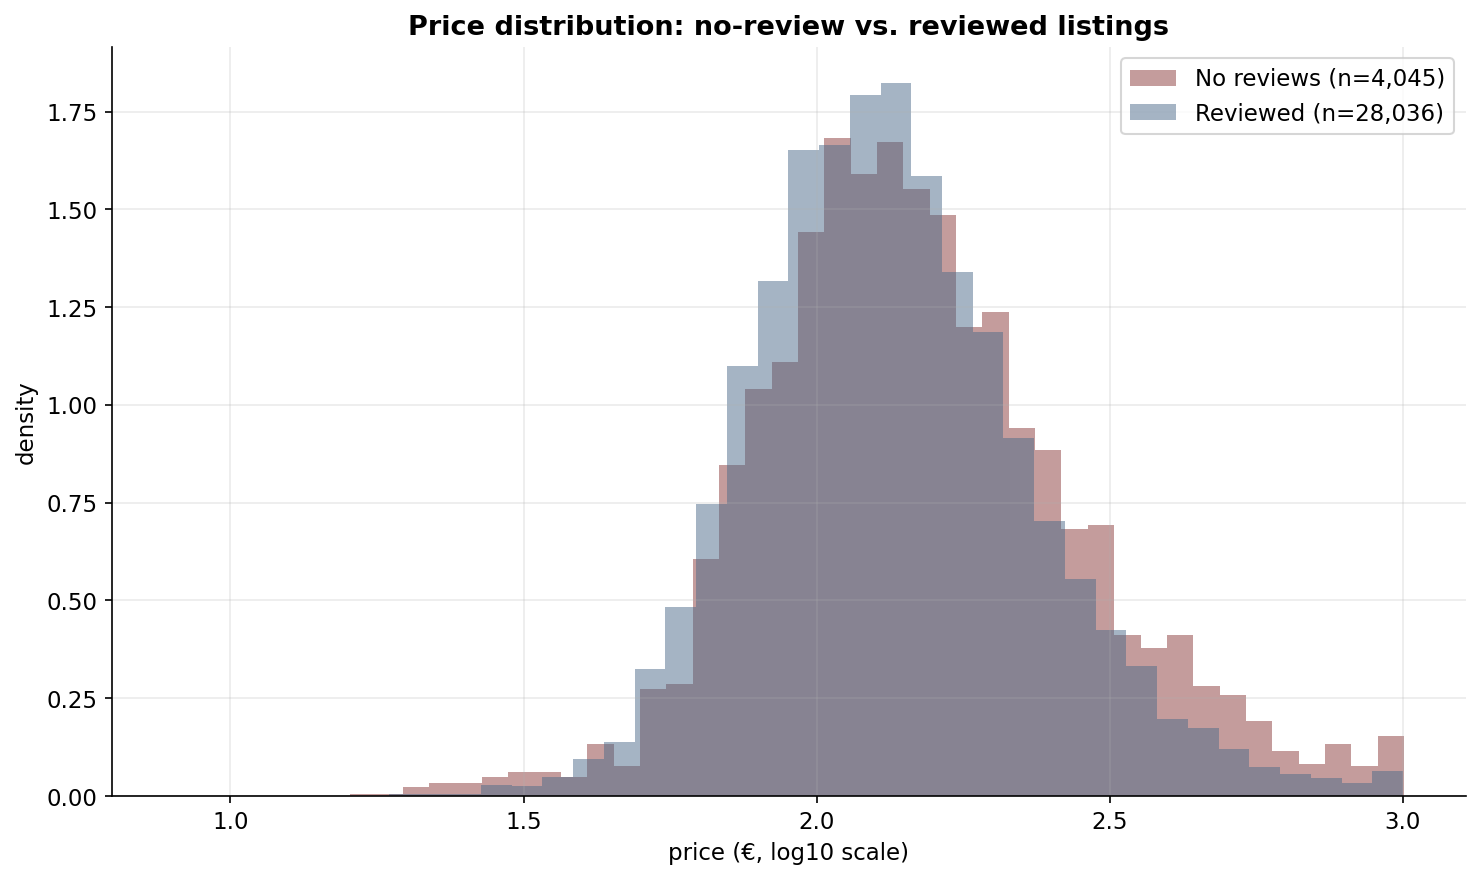

Mann-Whitney U test: p=0.0000000000000000 (significant difference)


In [24]:
fig, ax = plt.subplots(figsize=(10, 6))

for data, label, color in [(listings_no_review['price'].dropna(), 'No reviews', ROME_PALETTE['primary']),
                              (listings_reviewed['price'].dropna(), 'Reviewed', ROME_PALETTE['secondary'])]:
    log_data = np.log10(data[data > 0])
    ax.hist(log_data, bins=40, alpha=0.5, density=True, label=f'{label} (n={len(data):,})', color=color)

ax.set_xlabel('price (€, log10 scale)')
ax.set_ylabel('density')
ax.set_title('Price distribution: no-review vs. reviewed listings')
ax.legend()
plt.tight_layout()
plt.show()

from scipy.stats import mannwhitneyu
stat, pval = mannwhitneyu(listings_no_review['price'].dropna(), listings_reviewed['price'].dropna())
print(f"Mann-Whitney U test: p={pval:.16f} ({'significant' if pval < 0.05 else 'not significant'} difference)")

### 2.3 Property Type & Structure Comparison

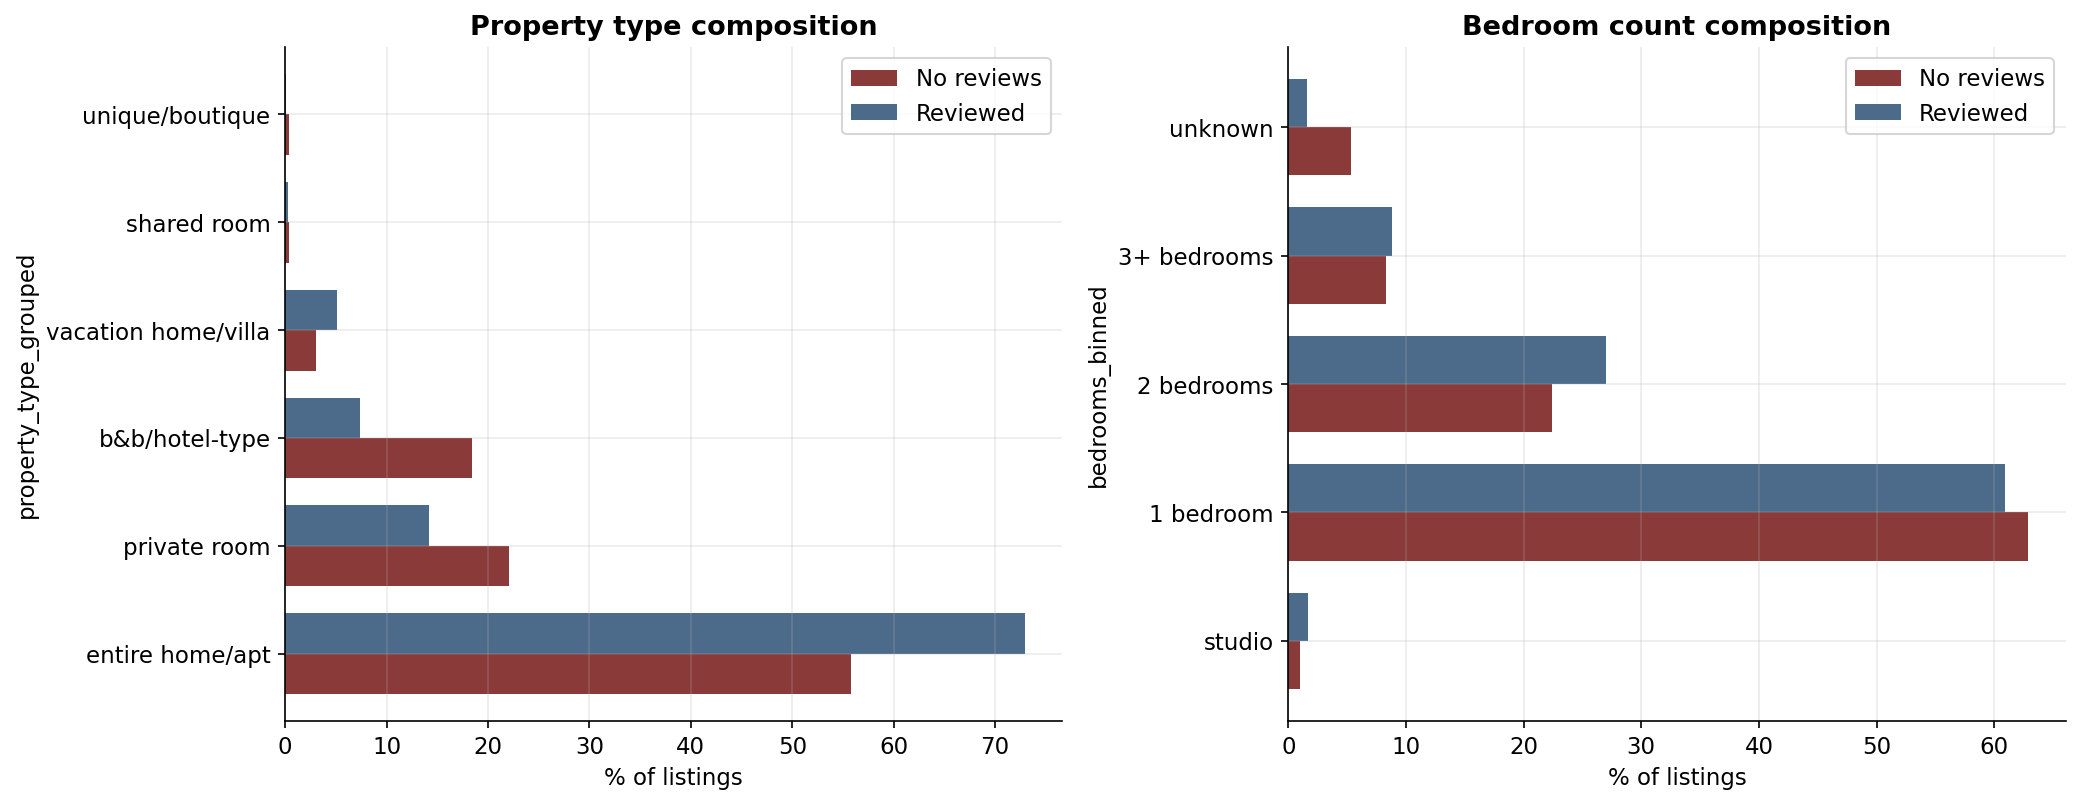

,No reviews,Reviewed
property_type_grouped,,
entire home/apt,55.7,73.0
private room,22.1,14.2
b&b/hotel-type,18.4,7.4
vacation home/villa,3.0,5.1
shared room,0.4,0.3
unique/boutique,0.3,0.1


,No reviews,Reviewed
bedrooms_binned,,
studio,1.0,1.7
1 bedroom,62.9,60.9
2 bedrooms,22.4,27.0
3+ bedrooms,8.3,8.8
unknown,5.4,1.6


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

no_review_prop = listings_no_review['property_type_grouped'].str.lower().value_counts(normalize=True).mul(100)
reviewed_prop = listings_reviewed['property_type_grouped'].value_counts(normalize=True).mul(100)

prop_compare = pd.DataFrame({'No reviews': no_review_prop, 'Reviewed': reviewed_prop}).fillna(0)
prop_compare.plot(kind='barh', ax=axes[0], color=[ROME_PALETTE['primary'], ROME_PALETTE['secondary']], width=0.75)
axes[0].set_xlabel('% of listings')
axes[0].set_title('Property type composition')

no_review_bed = listings_no_review['bedrooms_binned'].str.lower().value_counts(normalize=True).mul(100)
reviewed_bed = listings_reviewed['bedrooms_binned'].value_counts(normalize=True).mul(100)
bed_order = [b for b in ['studio', '1 bedroom', '2 bedrooms', '3+ bedrooms', 'unknown'] if b in no_review_bed.index or b in reviewed_bed.index]

bed_compare = pd.DataFrame({'No reviews': no_review_bed, 'Reviewed': reviewed_bed}).reindex(bed_order).fillna(0)
bed_compare.plot(kind='barh', ax=axes[1], color=[ROME_PALETTE['primary'], ROME_PALETTE['secondary']], width=0.75)
axes[1].set_xlabel('% of listings')
axes[1].set_title('Bedroom count composition')

plt.tight_layout()
plt.show()

display(prop_compare.round(1))
display(bed_compare.round(1))

Property type shows a structural difference: no-review listings skew toward B&B/hotel-type and private rooms, while the reviewed population is more concentrated in entire home/apt. This makes sense alongside the earlier portfolio-size finding: B&B/hotel-type listings often belong to small commercial operations, which may list many units at once, structurally diluting how quickly any single one accumulates its first reviews. Bedroom count, by contrast, shows almost no difference between the two populations.

### 2.4 Geographic Distribution Comparison

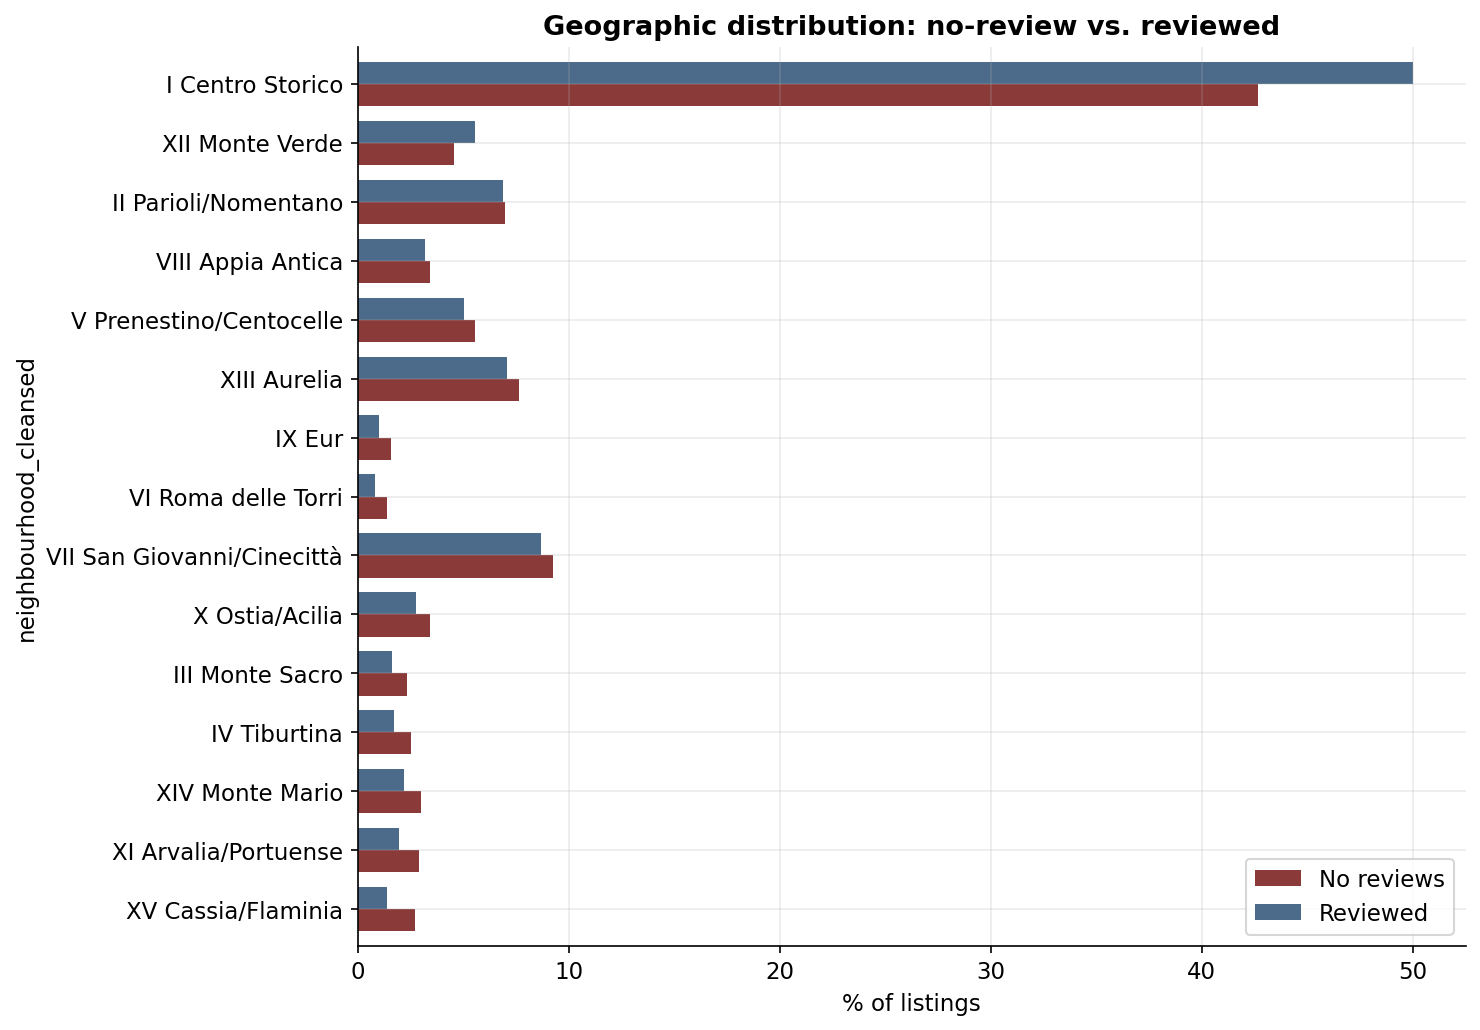

,No reviews,Reviewed,difference
neighbourhood_cleansed,,,
XV Cassia/Flaminia,2.7,1.4,1.3
XI Arvalia/Portuense,2.9,2.0,0.9
XIV Monte Mario,3.0,2.2,0.8
IV Tiburtina,2.5,1.7,0.8
III Monte Sacro,2.3,1.7,0.7
X Ostia/Acilia,3.4,2.8,0.7
VII San Giovanni/Cinecittà,9.3,8.7,0.6
VI Roma delle Torri,1.4,0.8,0.6
IX Eur,1.6,1.0,0.6


In [28]:
no_review_geo = listings_no_review['neighbourhood_cleansed'].value_counts(normalize=True).mul(100)
reviewed_geo = listings_reviewed['neighbourhood_cleansed'].value_counts(normalize=True).mul(100)

geo_compare = pd.DataFrame({'No reviews': no_review_geo, 'Reviewed': reviewed_geo}).fillna(0)
geo_compare['difference'] = geo_compare['No reviews'] - geo_compare['Reviewed']
geo_compare = geo_compare.sort_values('difference', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
geo_compare[['No reviews', 'Reviewed']].plot(kind='barh', ax=ax, color=[ROME_PALETTE['primary'], ROME_PALETTE['secondary']], width=0.75)
ax.set_xlabel('% of listings')
ax.set_title('Geographic distribution: no-review vs. reviewed')
plt.tight_layout()
plt.show()

display(geo_compare.round(1))

Geographic distribution is largely flat. Most municipi differ by under 1 percentage point between the two populations, with one meaningful exception: **I Centro Storico is under-represented among no-review listings by 7.3 points**,. This is the single clearest geographic signal in this comparison: the market's densest and most saturated district, is where a new listing has the hardest time staying review-less, plausibly because it's also the most search-visible, most frequently booked area, so listings there accumulate their first review fastest. No-review listings correspondingly skew slightly toward every other municipio, spread thinly rather than concentrated in any one peripheral area.

### 2.5 Host & Stay-Orientation Check

/var/folders/s_/9j10gw751dgb6tbppsps9d7w0000gn/T/ipykernel_67048/3956479842.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(portfolio_data, labels=['No reviews', 'Reviewed'], showfliers=False)


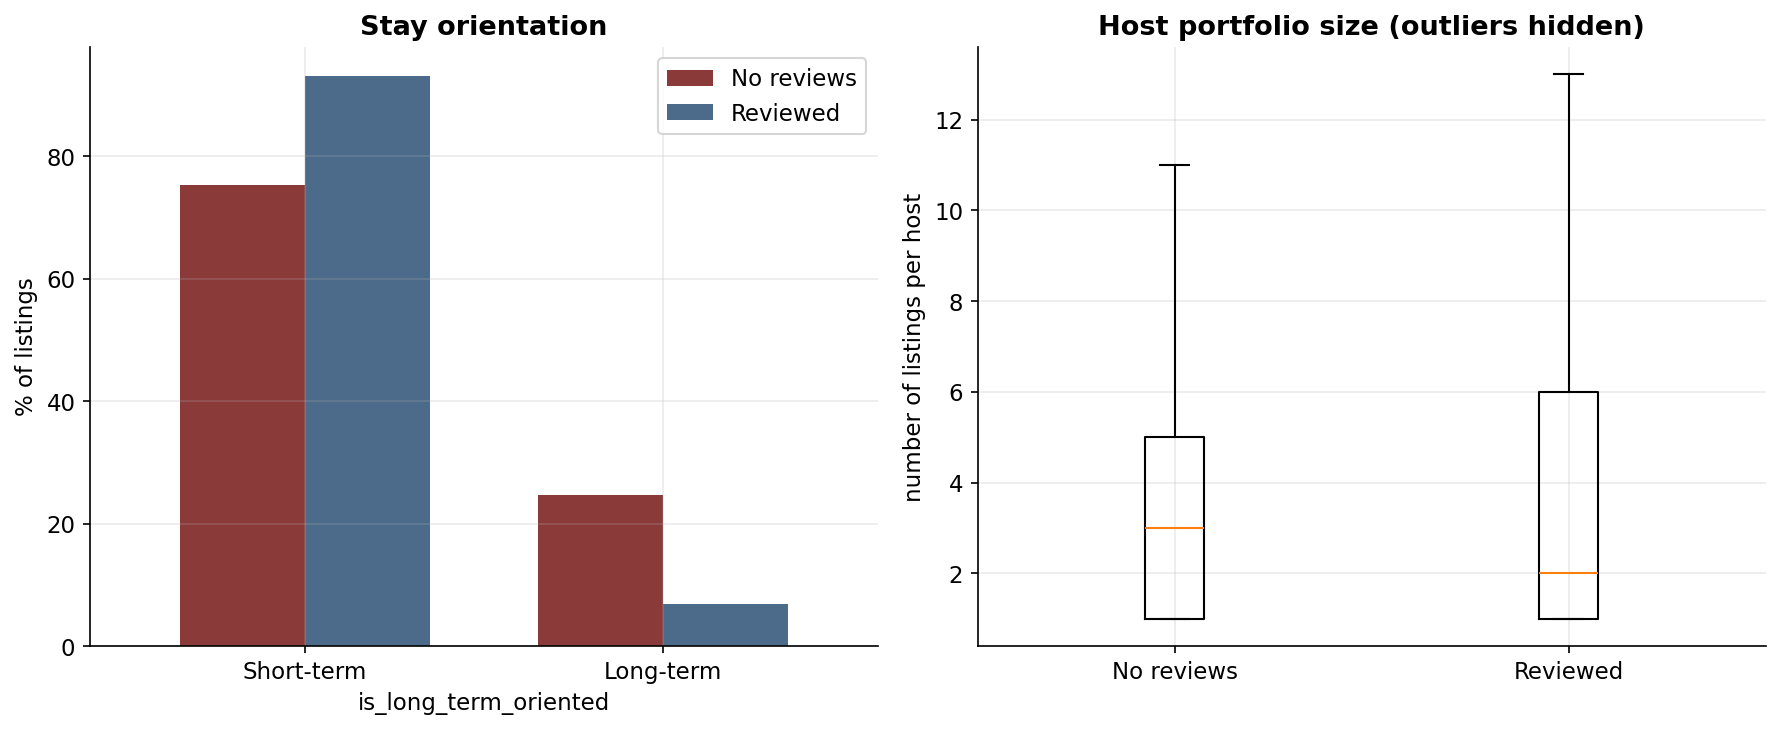

,No reviews,Reviewed
is_long_term_oriented,,
Short-term,75.3,93.2
Long-term,24.7,6.8


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

lt_compare = pd.DataFrame({
    'No reviews': listings_no_review['is_long_term_oriented'].value_counts(normalize=True).mul(100),
    'Reviewed': listings_reviewed['is_long_term_oriented'].value_counts(normalize=True).mul(100),
}).rename(index={0: 'Short-term', 1: 'Long-term'})
lt_compare.plot(kind='bar', ax=axes[0], color=[ROME_PALETTE['primary'], ROME_PALETTE['secondary']], width=0.7)
axes[0].set_title('Stay orientation')
axes[0].set_ylabel('% of listings')
axes[0].tick_params(axis='x', rotation=0)

portfolio_data = [
    listings_no_review['calculated_host_listings_count_log'].apply(np.expm1),
    listings_reviewed['calculated_host_listings_count_log'].apply(np.expm1),
]
axes[1].boxplot(portfolio_data, labels=['No reviews', 'Reviewed'], showfliers=False)
axes[1].set_title('Host portfolio size (outliers hidden)')
axes[1].set_ylabel('number of listings per host')

plt.tight_layout()
plt.show()

display(lt_compare.round(1))

Long-term orientation is the sharpest structural signal found in this comparison: 24.7% of no-review listings are long-term oriented, versus just 6.8% of reviewed listings. This directly explains the "no-review" mechanism itself: `is_long_term_oriented` was built in feature engineering around a ~28-30 day minimum-stay threshold, and Airbnb's own review system requires a completed stay before a guest can leave one. A month-plus minimum stay structurally produces far fewer completed bookings per unit time than a 1-3 night listing, so slower review accumulation is a direct consequence of how the listing is offered.

Portfolio size, however, runs in the *opposite* direction from the boxplot's visual impression: no-review listings show a **higher** median (3 vs. 2), even though the reviewed population's box stretches to a higher upper quartile and whisker. Both facts are true simultaneously: no-review hosts are more uniformly mid-sized operators, while reviewed listings include both more single-unit hosts *and* more large operators.

### 2.6 No-Review Strata Summary

The 14.2% of listings with no reviews differ from the reviewed population across several dimensions at once: they're modestly higher-priced, sit slightly further from the center, skew toward B&B/hotel-type and private-room configurations, and are somewhat under-represented in I Centro Storico specifically. The clearest single driver is stay orientation, which only accounts for a minority of the no-review population.

These listings are set aside from the clustering that follows, since their defining trait is an absence rather than a comparable market position, and mixing that structural difference into the same distance calculation risks building a cluster around it instead of genuine segmentation.